In [1]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7, 
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [2]:
import numpy as np
np.column_stack(([1,2,3],[4,5,6]))

array([[1, 4],
       [2, 5],
       [3, 6]])

In [3]:
fish_data = np.column_stack((fish_length, fish_weight))
fish_data[:5]

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

In [4]:
np.ones(5)

array([1., 1., 1., 1., 1.])

In [6]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))
fish_target

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [11]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42)

In [12]:
# 2차원 배열
train_input.shape, test_input.shape

((36, 2), (13, 2))

In [14]:
# 1차원 배열
train_target.shape, test_target.shape

((36,), (13,))

In [15]:
test_target

array([1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [17]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)

In [18]:
# 2.25:1
test_target

array([0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

In [19]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [20]:
kn.predict([[25, 150]])

array([0.])

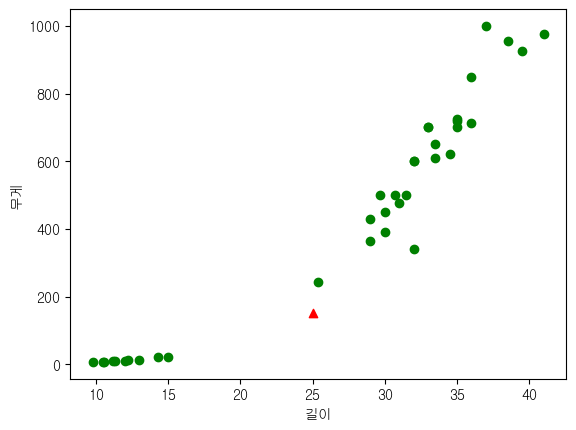

In [23]:
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', family='Gulim')

plt.scatter(train_input[:,0], train_input[:,1], c='g')
plt.scatter(25, 150, marker='^', c='r')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [25]:
distances, indexes = kn.kneighbors([[25, 150]])
distances, indexes

(array([[ 92.00086956, 130.48375378, 130.73859415, 138.32150953,
         138.39320793]]),
 array([[21, 33, 19, 30,  1]]))

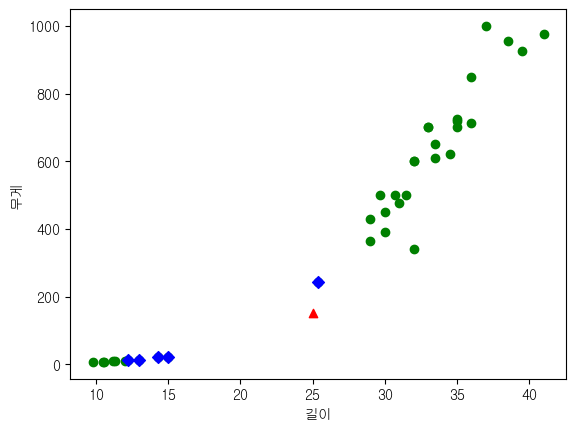

In [27]:
plt.scatter(train_input[:,0], train_input[:,1], c='g')
plt.scatter(25, 150, marker='^', c='r')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D', c='b')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [28]:
train_target[indexes]

array([[1., 0., 0., 0., 0.]])

In [29]:
distances

array([[ 92.00086956, 130.48375378, 130.73859415, 138.32150953,
        138.39320793]])

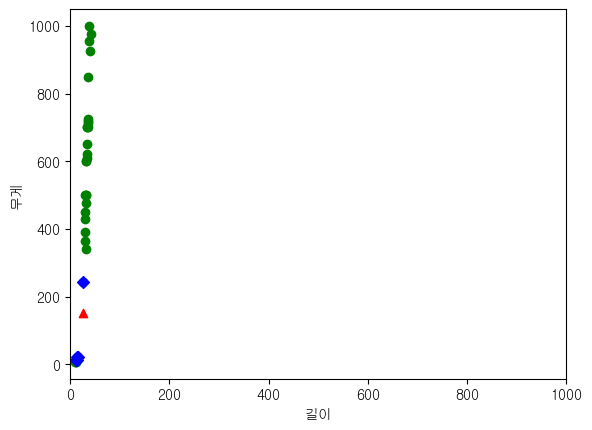

In [30]:
plt.scatter(train_input[:,0], train_input[:,1], c='g')
plt.scatter(25, 150, marker='^', c='r')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D', c='b')
plt.xlim((0, 1000))
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [34]:
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)
mean, std

(array([ 27.29722222, 454.09722222]), array([  9.98244253, 323.29893931]))

In [35]:
train_scaled = (train_input - mean) / std

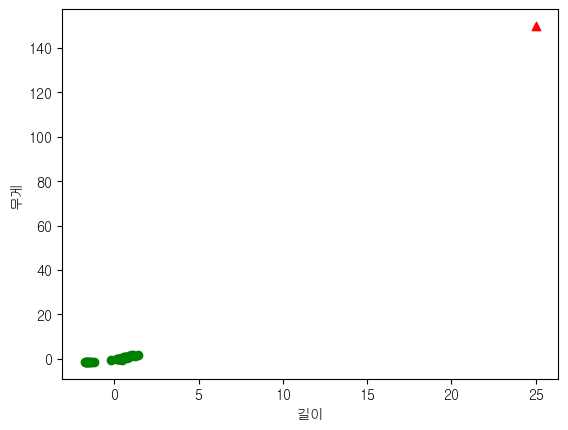

In [36]:
plt.scatter(train_scaled[:,0], train_scaled[:,1], c='g')
plt.scatter(25, 150, marker='^', c='r')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

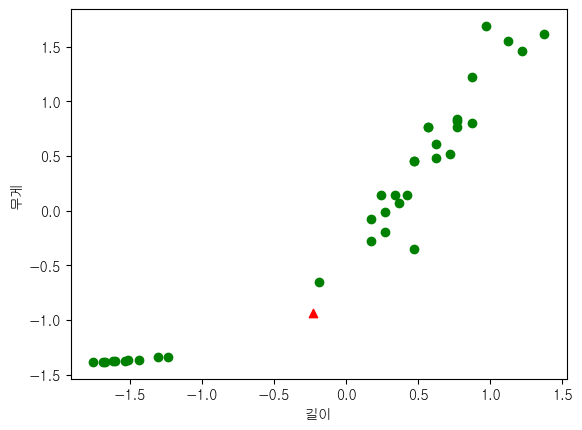

In [38]:
new = ([25, 150] - mean) / std
plt.scatter(train_scaled[:,0], train_scaled[:,1], c='g')
plt.scatter(new[0], new[1], marker='^', c='r')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [39]:
kn.fit(train_scaled, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [40]:
test_scaled = (test_input - mean) / std

In [41]:
kn.score(test_scaled, test_target)

1.0

In [42]:
kn.predict([new])

array([1.])

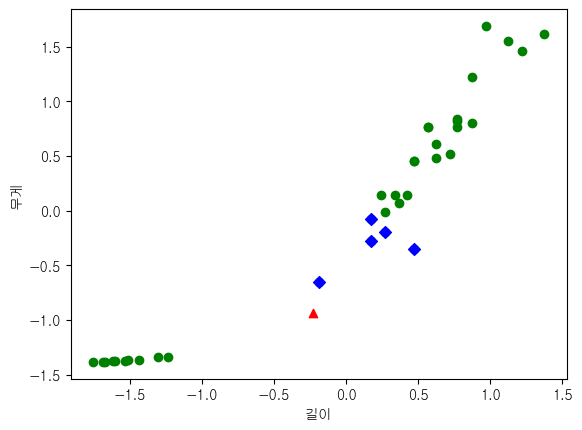

In [44]:
distances, indexes = kn.kneighbors([new])
plt.scatter(train_scaled[:,0], train_scaled[:,1], c='g')
plt.scatter(new[0], new[1], marker='^', c='r')
plt.scatter(train_scaled[indexes,0], train_scaled[indexes,1], marker='D', c='b')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()